In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import QuantileRegressor
from sklearn.preprocessing import PolynomialFeatures

In [8]:
def plot_quantile_trend(df_sel, feature_name, ylabel, df_one=None, quantiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]):
    # Skalowanie
    scaler = RobustScaler()
    df_male = df_sel[df_sel['male'] == 1]
    df_female = df_sel[df_sel['male'] == 0]
    dfs = [df_male, df_female]
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    for j, df in enumerate(dfs):
        y_scaled = scaler.fit_transform(df[[feature_name]]).ravel()
        age = df['age'].values.reshape(-1,1)

        # Predykcje kwantylowe
        age_space = np.linspace(age.min(), age.max(), 200).reshape(-1,1)
        quantile_lines = {}
        for q in quantiles:
            qr_pipeline = make_pipeline(
                PolynomialFeatures(degree=2, include_bias=False),
                QuantileRegressor(quantile=q, alpha=0)
            )
            qr_pipeline.fit(age, y_scaled)
            coef = qr_pipeline.named_steps['quantileregressor'].coef_
            intercept = qr_pipeline.named_steps['quantileregressor'].intercept_
            quantile_lines[q] = coef[1]*age_space**2 + coef[0]*age_space + intercept


        #subplot

        axes[j].scatter(age, y_scaled, color='blue', alpha=0.5, label='Dane przeskalowane')

        # trend mediany
        axes[j].plot(age_space, quantile_lines[0.5], color='red', linewidth=2, label='q=0.5')

        # percentyle
        colors = plt.cm.viridis(np.linspace(0,1,len(quantiles)))
        for i, q in enumerate(quantiles):
            if q == 0.5:
                continue  # medianę już mamy
            axes[j].plot(age_space, quantile_lines[q], color=colors[i], linestyle='--', label=f'q={q}')
        if df_one is not None:
            y_one_scaled=scaler.transform(df_one[[feature_name]]).ravel()
            age_one=df_one['age']
            axes[j].scatter(age_one.values, y_one_scaled, color='red', s=100, marker='X', label='Próbka osoby')

        axes[j].set_xlabel('Wiek [lata]', fontsize=16)
        axes[j].set_ylabel(ylabel, fontsize=13)
        axes[j].legend(fontsize=12)
        #bigger ticks
        axes[j].tick_params(axis='both', which='major', labelsize=15)
    plt.show()

In [4]:
%cd ..

/home/marysia/Documents/GitHub/MRI_machine_learning


In [5]:
df_positive = pd.read_csv('data/positive_norm_confirmed/all_concatenated.csv', sep=None, engine='python')
df_positive_filtered = df_positive[(df_positive['age'] >= 0) & (df_positive['age'] <= 100)]
df_positive_male = df_positive_filtered[df_positive_filtered['male'] == 1]
df_positive_female = df_positive_filtered[df_positive_filtered['male'] == 0]

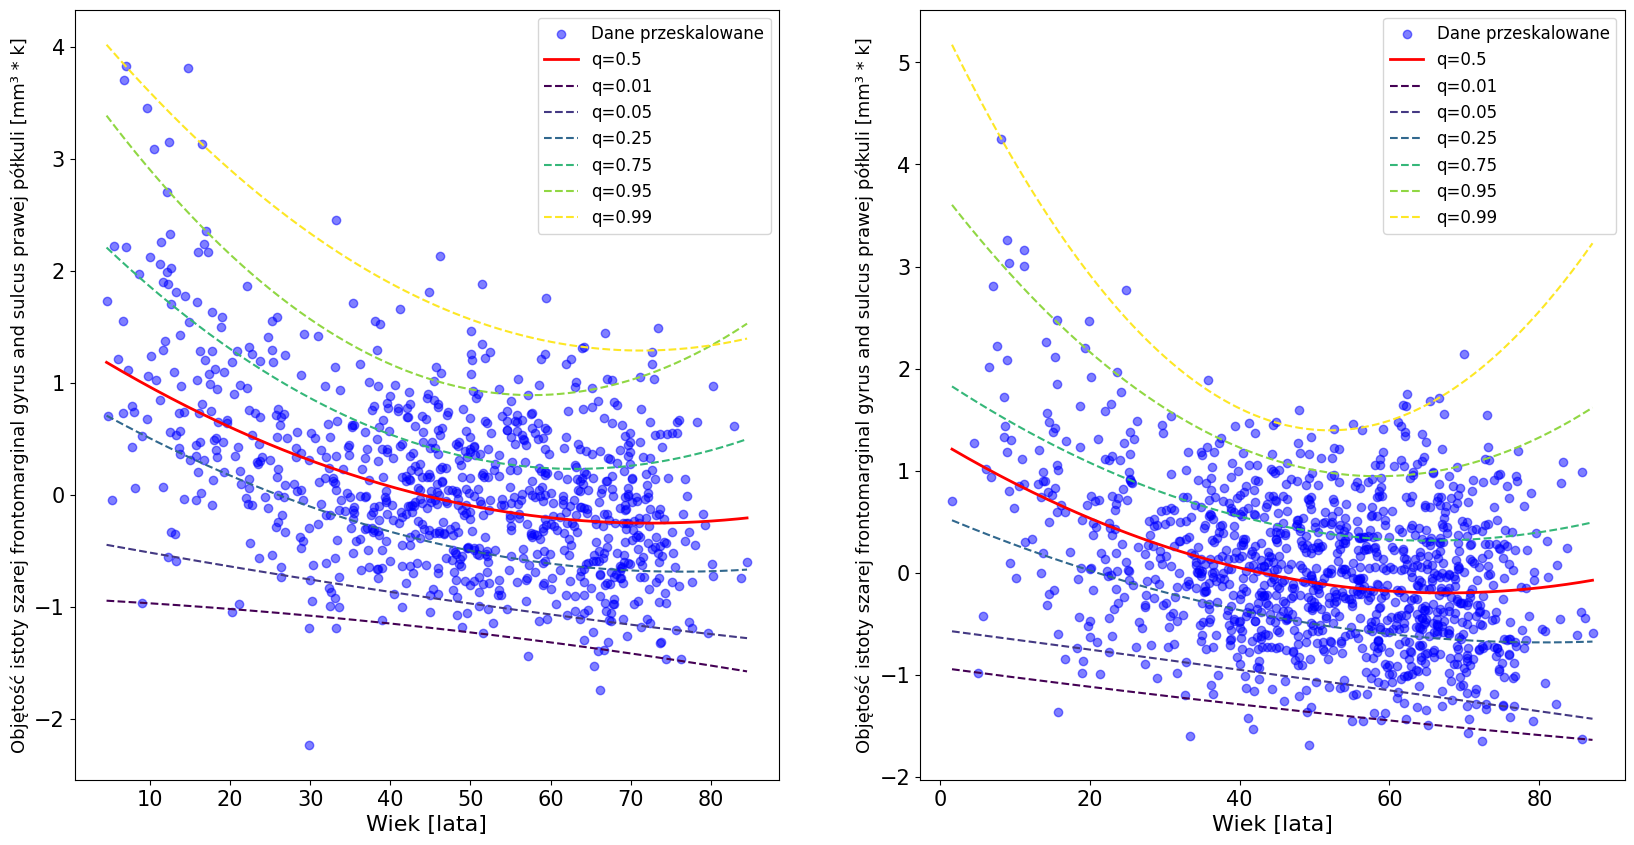

In [9]:
plot_quantile_trend(df_positive_filtered, 'A2009-ctx-rh-G_and_S_frontomargin_GrayVol', ylabel='Objętość istoty szarej frontomarginal gyrus and sulcus prawej półkuli [mm³ * k]', df_one=None)

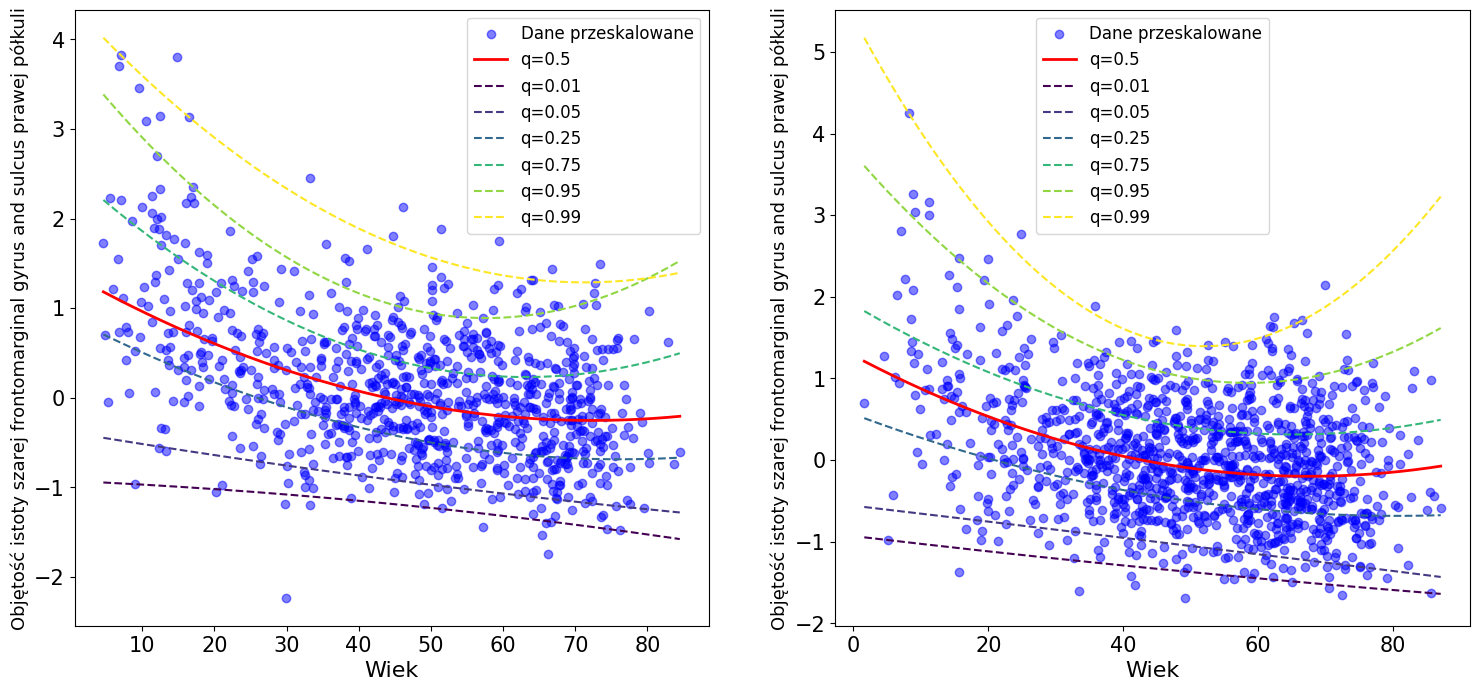

In [41]:
plot_quantile_trend(df_positive_filtered, 'A2009-ctx-rh-G_and_S_frontomargin_GrayVol', ylabel='Objętość istoty szarej frontomarginal gyrus and sulcus prawej półkuli')